In [28]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder

class FeedForwardNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(FeedForwardNetwork, self).__init__()
        self.ffn = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),  # Add dropout here
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x):
        return self.ffn(x)

class SimpleVATTEmotionPredictor(nn.Module):
    def __init__(self, audio_dim, text_dim, common_space_dim, hidden_dim, num_classes):
        super(SimpleVATTEmotionPredictor, self).__init__()

        self.audio_ffn = FeedForwardNetwork(audio_dim, hidden_dim)
        self.text_ffn = FeedForwardNetwork(text_dim, hidden_dim)

         # Projection heads for common spaces
        self.audio_to_va = nn.Sequential(
            nn.Linear(hidden_dim, common_space_dim),
            nn.BatchNorm1d(common_space_dim)
        )
        self.text_to_vt = nn.Sequential(
            nn.Linear(hidden_dim, common_space_dim),
            nn.BatchNorm1d(common_space_dim)
        )

         # The first linear layer should expect 2 * common_space_dim as input
        self.classifier = nn.Sequential(
            nn.Linear(common_space_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, audio_features, text_features):
        audio_hidden = self.audio_ffn(audio_features)
        text_hidden = self.text_ffn(text_features)

         # Project features into common spaces
        z_a_va = self.audio_to_va(audio_hidden)
        z_t_vt = self.text_to_vt(text_hidden)

         # Concatenate the common space outputs
        combined_embedding = torch.cat([z_a_va, z_t_vt], dim=-1)

        emotion_logits = self.classifier(combined_embedding)

        return emotion_logits

In [4]:
df_audio = pd.read_csv("/content/drive/MyDrive/audio_features.csv")
df_text = pd.read_csv("/content/drive/MyDrive/urdu_embeddings_from_tuned_xlmr_final.csv")

In [5]:
import os

df_audio["Link"] = df_audio["Link"].apply(lambda x: os.path.basename(str(x)))
df_text["Link"] = df_text["Link"].apply(lambda x: os.path.basename(str(x)))

In [6]:
df_merged = pd.merge(
    df_audio,
    df_text,
    left_on="Link",
    right_on="Link",
    how="inner"
)

print("Merged rows:", len(df_merged))

Merged rows: 8293


In [8]:
audio_columns = [col for col in df_audio.columns if col not in ["Link", "Label"]]

audio_features = df_merged[audio_columns].values

In [9]:
text_columns = [col for col in df_text.columns if col not in ["Link", "Label"]]

text_features = df_merged[text_columns].values

In [10]:
labels = df_merged["Label_x"].values
labels = df_merged["Label_y"].values

In [17]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)  # Converts happy -> 0, sad -> 1, etc.
print("Classes:", le.classes_)

classes = np.unique(labels_encoded)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=labels_encoded
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

Classes: ['Anger' 'Happy' 'Love' 'Neutral' 'Sad']


In [19]:
from sklearn.model_selection import train_test_split

# First split: Train (70%) and Temp (30%)
audio_train, audio_temp, text_train, text_temp, y_train, y_temp = train_test_split(
    audio_features,
    text_features,
    labels_encoded,
    test_size=0.30,
    random_state=42,
    stratify=labels_encoded
)

# Second split: Temp -> Validation (15%) + Test (15%)
audio_val, audio_test, text_val, text_test, y_val, y_test = train_test_split(
    audio_temp,
    text_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [21]:
from sklearn.preprocessing import StandardScaler

# Separate scalers
scaler_audio = StandardScaler()
scaler_text = StandardScaler()

# Fit ONLY on training data
audio_train = scaler_audio.fit_transform(audio_train)
text_train = scaler_text.fit_transform(text_train)

# Transform validation and test
audio_val = scaler_audio.transform(audio_val)
audio_test = scaler_audio.transform(audio_test)

text_val = scaler_text.transform(text_val)
text_test = scaler_text.transform(text_test)

In [22]:
import torch

audio_train = torch.tensor(audio_train, dtype=torch.float32)
audio_val = torch.tensor(audio_val, dtype=torch.float32)
audio_test = torch.tensor(audio_test, dtype=torch.float32)

text_train = torch.tensor(text_train, dtype=torch.float32)
text_val = torch.tensor(text_val, dtype=torch.float32)
text_test = torch.tensor(text_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [24]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(audio_train, text_train, y_train)
val_dataset = TensorDataset(audio_val, text_val, y_val)
test_dataset = TensorDataset(audio_test, text_test, y_test)

In [25]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [29]:
text_dim = text_train.shape[1]
audio_dim = audio_train.shape[1]

model = SimpleVATTEmotionPredictor(
    audio_dim=audio_dim,
    text_dim=text_dim,
    common_space_dim=128,
    hidden_dim=256,
    num_classes=len(set(labels_encoded))
)

In [30]:
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


best_val_loss = float('inf')
patience = 5  # Number of epochs to wait for improvement
counter = 0
epochs = 50

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    for a, t, y in train_loader:
        a, t, y = a.to(device), t.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(a, t)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

    # --- Validation Phase ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for a, t, y in val_loader:
            a, t, y = a.to(device), t.to(device), y.to(device)
            outputs = model(a, t)
            loss = criterion(outputs, y)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1}, Val Loss: {avg_val_loss:.4f}")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.7f}")


    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth') # Save the best version
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break

Epoch 1, Val Loss: 0.9448
Learning Rate: 0.0001000
Epoch 2, Val Loss: 0.8368
Learning Rate: 0.0001000
Epoch 3, Val Loss: 0.7991
Learning Rate: 0.0001000
Epoch 4, Val Loss: 0.7957
Learning Rate: 0.0001000
Epoch 5, Val Loss: 0.8249
Learning Rate: 0.0001000
Epoch 6, Val Loss: 0.7919
Learning Rate: 0.0001000
Epoch 7, Val Loss: 0.8199
Learning Rate: 0.0001000
Epoch 8, Val Loss: 0.7907
Learning Rate: 0.0001000
Epoch 9, Val Loss: 0.8290
Learning Rate: 0.0001000
Epoch 10, Val Loss: 0.8365
Learning Rate: 0.0001000
Epoch 11, Val Loss: 0.8704
Learning Rate: 0.0000500
Epoch 12, Val Loss: 0.8847
Learning Rate: 0.0000500
Epoch 13, Val Loss: 0.8869
Learning Rate: 0.0000500
Early stopping triggered!


In [31]:
correct = 0
total = 0

with torch.no_grad():
    for a, t, y in test_loader:
        a, t, y = a.to(device), t.to(device), y.to(device)
        outputs = model(a, t)
        _, predicted = torch.max(outputs, 1)

        total += y.size(0)
        correct += (predicted == y).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 72.11%


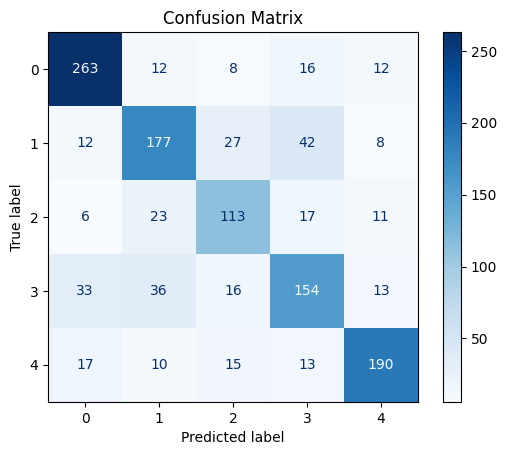

Accuracy: 72.1061
Report :
               precision    recall  f1-score   support

           0       0.79      0.85      0.82       311
           1       0.69      0.67      0.68       266
           2       0.63      0.66      0.65       170
           3       0.64      0.61      0.62       252
           4       0.81      0.78      0.79       245

    accuracy                           0.72      1244
   macro avg       0.71      0.71      0.71      1244
weighted avg       0.72      0.72      0.72      1244



In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for a, t, y in test_loader:
        a, t = a.to(device), t.to(device)
        outputs = model(a, t)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(all_labels, all_preds)
print(f"Accuracy: {accuracy:.4f}")
print("Report :\n", report)